# Notebook 02 — Features and Kernels

Notebook 01 trained every classifier directly on raw pixels. Here we ask a different
question: **is a limitation caused by the learning rule, or by the representation
given to it?**

We look at three ways of changing the representation seen by a linear classifier:
PCA (dimensionality reduction), an explicit cubic feature map, and two kernels
(polynomial and RBF) that compute inner products in an implicit feature space without
ever constructing that space explicitly.

In [1]:
import sys
sys.path.append("..")

import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

from classical.data_utils import get_MNIST_data, plot_images, make_train_val_split
from classical.features import center_data, principal_components, project_onto_PC, reconstruct_PC, cubic_features
from classical.kernel import polynomial_kernel, rbf_kernel
from classical.softmax import softmax_regression, compute_test_error

np.random.seed(12321)

## 1. Raw pixels — the reference representation

We reuse Softmax regression on raw pixels from Notebook 01 as the reference point for
every representation change below.

In [2]:
train_x, train_y, test_x, test_y = get_MNIST_data()
train_x_sub, train_y_sub, val_x, val_y = make_train_val_split(train_x, train_y, val_fraction=0.1)

# Use a moderate-sized subset so PCA/kernel experiments below stay fast to run.
n_train, n_val, n_test = 4000, 1000, 1000
train_x_sub, train_y_sub = train_x_sub[:n_train], train_y_sub[:n_train]
val_x, val_y = val_x[:n_val], val_y[:n_val]
test_x_small, test_y_small = test_x[:n_test], test_y[:n_test]

theta_raw, _ = softmax_regression(
    train_x_sub, train_y_sub, temp_parameter=1, alpha=0.3, lambda_factor=1e-4, k=10, num_iterations=150
)
raw_val_error = compute_test_error(val_x, val_y, theta_raw, temp_parameter=1)
raw_test_error = compute_test_error(test_x_small, test_y_small, theta_raw, temp_parameter=1)
print(f"Raw pixels  | val error: {raw_val_error:.4f}  test error: {raw_test_error:.4f}")

Raw pixels  | val error: 0.1170  test error: 0.1160


## 2. PCA

PCA re-expresses each image in terms of the directions of greatest variance in the
training data, and lets us keep only the first $n$ of them. This is a **linear**,
*data-dependent* change of representation — no new nonlinear structure is added, but
much of the redundancy in 784 raw pixel values can often be discarded with little loss
of information.

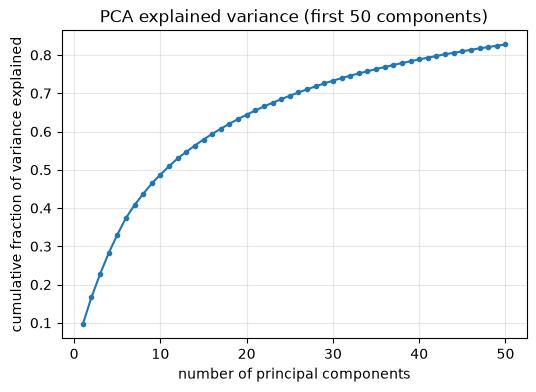

In [3]:
centered_train, feature_means = center_data(train_x_sub)
pcs = principal_components(centered_train)

# Explained-variance diagnostic
scatter = centered_train.T @ centered_train
eig_vals_full = np.sort(np.linalg.eigvalsh(scatter))[::-1]
explained = eig_vals_full[:50] / np.sum(eig_vals_full)
cumulative = np.cumsum(explained)

plt.figure(figsize=(6, 4))
plt.plot(np.arange(1, 51), cumulative, marker="o", markersize=3)
plt.xlabel("number of principal components")
plt.ylabel("cumulative fraction of variance explained")
plt.title("PCA explained variance (first 50 components)")
plt.grid(alpha=0.3)
plt.show()

A small number of principal components already explains a large fraction of the
pixel variance. We can also see this directly, by reconstructing a digit from only its
first few principal components.

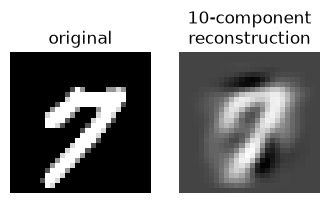

In [4]:
example = train_x_sub[0:1]
example_pca = project_onto_PC(example, pcs, n_components=10, feature_means=feature_means)
example_recon = reconstruct_PC(example_pca, pcs, n_components=10, feature_means=feature_means)

fig, axes = plt.subplots(1, 2, figsize=(4, 2))
axes[0].imshow(example.reshape(28, 28), cmap="Greys_r")
axes[0].set_title("original")
axes[0].axis("off")
axes[1].imshow(example_recon.reshape(28, 28), cmap="Greys_r")
axes[1].set_title("10-component\nreconstruction")
axes[1].axis("off")
plt.show()

In [5]:
n_components = 30
train_pca = project_onto_PC(train_x_sub, pcs, n_components, feature_means)
val_pca = project_onto_PC(val_x, pcs, n_components, feature_means)
test_pca = project_onto_PC(test_x_small, pcs, n_components, feature_means)

theta_pca, _ = softmax_regression(
    train_pca, train_y_sub, temp_parameter=1, alpha=0.3, lambda_factor=1e-4, k=10, num_iterations=150
)
pca_val_error = compute_test_error(val_pca, val_y, theta_pca, temp_parameter=1)
pca_test_error = compute_test_error(test_pca, test_y_small, theta_pca, temp_parameter=1)
print(f"PCA ({n_components} components) | val error: {pca_val_error:.4f}  test error: {pca_test_error:.4f}")

PCA (30 components) | val error: 0.1410  test error: 0.1440


PCA with far fewer than 784 dimensions reaches comparable error to raw pixels for
Softmax regression. This shows that most of the raw pixel representation was
redundant for this classifier — but PCA is still a **linear** transform, so it cannot,
by itself, give the classifier access to nonlinear decision boundaries.

## 3. Cubic features

A feature map $\phi(x)$ sends each input into a (typically higher-dimensional) space
in which a linear classifier corresponds to a **nonlinear** boundary in the original
space. The cubic feature map used here expands a $d$-dimensional (plus bias) vector
into every monomial of degree 3, scaled so that

$$
\phi(x)^{T}\phi(z) = (x^{T}z + 1)^{3}.
$$

We first demonstrate the expansion on a tiny 2-dimensional vector, where the output
can be inspected directly, before discussing why this is impractical to apply to full
MNIST images.

In [6]:
tiny_example = np.array([[1.0, 2.0]])
tiny_features = cubic_features(tiny_example)
print("input dimension:", tiny_example.shape[1])
print("cubic feature dimension:", tiny_features.shape[1])
print("(1 + 2)-d input -> (d+1)(d+2)(d+3)/6 = 4*5*6/6 =", int(4 * 5 * 6 / 6), "features")

input dimension: 2
cubic feature dimension: 10
(1 + 2)-d input -> (d+1)(d+2)(d+3)/6 = 4*5*6/6 = 20 features


For MNIST, $d = 784$, so the cubic feature dimension would be

$$
\frac{(d+1)(d+2)(d+3)}{6}\approx 8.1\times10^{7}.
$$

Constructing and storing $\phi(x)$ explicitly for every training image at that
dimension is not practical. This is exactly the situation the polynomial **kernel**
below is designed for: it computes $\phi(x)^{T}\phi(z)$ directly, without ever forming
$\phi(x)$.

In [7]:
d = 784
cubic_dim = (d + 1) * (d + 2) * (d + 3) // 6
print(f"Cubic feature dimension for MNIST: {cubic_dim:,}")

Cubic feature dimension for MNIST: 80,931,145


## 4. Polynomial kernel

The polynomial kernel is

$$
K(x, z) = (x^{T}z + c)^{p}.
$$

For $p = 3$, this kernel computes the *same inner product* as the cubic feature map
above, but the computation is $O(d)$ per pair instead of $O(d^{3})$ — the kernel never
constructs the 81-million-dimensional vector, it only ever needs the scalar dot
product $x^{T}z$.

We use a kernel Support Vector Machine here (`sklearn.svm.SVC` with a polynomial
kernel) to demonstrate classification performance with this representation.

In [8]:
# Direct inspection of the kernel matrix on a handful of images
K_poly = polynomial_kernel(train_x_sub[:5], train_x_sub[:5], c=1, p=3)
print("Polynomial kernel matrix (5x5 example):")
print(np.round(K_poly / 1e6, 2), "(x 1e6)")

Polynomial kernel matrix (5x5 example):
[[1.29 0.05 0.09 0.39 0.06]
 [0.05 0.42 0.17 0.45 0.04]
 [0.09 0.17 1.88 0.77 0.06]
 [0.39 0.45 0.77 4.44 0.42]
 [0.06 0.04 0.06 0.42 0.59]] (x 1e6)


In [9]:
poly_clf = SVC(kernel="poly", degree=3, coef0=1, C=1.0)
poly_clf.fit(train_x_sub, train_y_sub)

poly_val_error = 1 - poly_clf.score(val_x, val_y)
poly_test_error = 1 - poly_clf.score(test_x_small, test_y_small)
print(f"Polynomial kernel SVM | val error: {poly_val_error:.4f}  test error: {poly_test_error:.4f}")

Polynomial kernel SVM | val error: 0.0590  test error: 0.0520


## 5. RBF kernel

The Gaussian RBF kernel is

$$
K(x, z) = \exp(-\gamma\lVert x - z\rVert^{2}),
$$

which corresponds to an *infinite*-dimensional implicit feature space. The scale
parameter $\gamma$ controls how quickly similarity falls off with distance: a large
$\gamma$ makes the kernel very locally sensitive (similar only to near-identical
images), while a small $\gamma$ makes it behave closer to a smooth, global
similarity measure.

gamma=0.1      val error: 0.1970
gamma=0.01     val error: 0.0610
gamma=0.001    val error: 0.1030


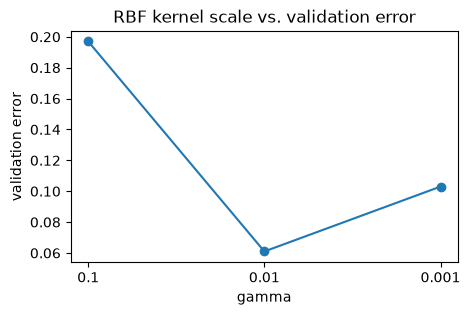

In [10]:
gammas = [0.1, 0.01, 0.001]
val_errors = []

for gamma in gammas:
    clf = SVC(kernel="rbf", gamma=gamma, C=1.0)
    clf.fit(train_x_sub, train_y_sub)
    val_error = 1 - clf.score(val_x, val_y)
    val_errors.append(val_error)
    print(f"gamma={gamma:<8} val error: {val_error:.4f}")

plt.figure(figsize=(5, 3))
plt.plot([str(g) for g in gammas], val_errors, marker="o")
plt.xlabel("gamma")
plt.ylabel("validation error")
plt.title("RBF kernel scale vs. validation error")
plt.show()

## 6. Model selection

The RBF scale above was chosen by comparing **validation** error only. We now retrain
the best-performing configuration and evaluate it once, on the untouched test set.

In [11]:
best_gamma = gammas[int(np.argmin(val_errors))]
print("Selected gamma (by validation error):", best_gamma)

best_rbf_clf = SVC(kernel="rbf", gamma=best_gamma, C=1.0)
best_rbf_clf.fit(train_x_sub, train_y_sub)
rbf_test_error = 1 - best_rbf_clf.score(test_x_small, test_y_small)
print(f"Selected RBF kernel SVM | test error: {rbf_test_error:.4f}")

Selected gamma (by validation error): 0.01
Selected RBF kernel SVM | test error: 0.0680


## 7. Comparison across representations

In [12]:
import pandas as pd

comparison = pd.DataFrame(
    {
        "representation": ["Raw pixels (Softmax)", f"PCA-{n_components} (Softmax)", "Polynomial kernel SVM", "RBF kernel SVM"],
        "validation error": [raw_val_error, pca_val_error, poly_val_error, val_errors[int(np.argmin(val_errors))]],
        "test error": [raw_test_error, pca_test_error, poly_test_error, rbf_test_error],
    }
)
comparison

,representation,validation error,test error
0,Raw pixels (Softmax),0.117,0.116
1,PCA-30 (Softmax),0.141,0.144
2,Polynomial kernel SVM,0.059,0.052
3,RBF kernel SVM,0.061,0.068


## Study questions

1. Why does a nonlinear feature map allow a linear classifier to represent nonlinear
   boundaries?
2. Why can a kernel be useful when explicitly constructing $\phi(x)$ is expensive?
3. What is the difference between changing the classifier and changing the
   representation?